In [2]:
import geopandas as gpd

In [3]:
cph = gpd.read_file("../../data/afstemningsomraader2025_CPH_FRB.geojson")

In [4]:
cph.info(verbose=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        66 non-null     str     
 1   afstemningsomraadenummer  66 non-null     int32   
 2   afstemningsstedNavn       66 non-null     str     
 3   kommuneLokalId            66 non-null     int32   
 4   navn                      66 non-null     str     
 5   opstillingskredsLokalId   66 non-null     int32   
 6   areaSquareMetres          66 non-null     float64 
 7   geometry                  66 non-null     geometry
dtypes: float64(1), geometry(1), int32(3), str(3)
memory usage: 5.5 KB


In [5]:
cph.head()

,id,afstemningsomraadenummer,afstemningsstedNavn,kommuneLokalId,navn,opstillingskredsLokalId,areaSquareMetres,geometry
0,247,4,Skolen på Duevej,389104,"10. Kreds, Duevej",403570,1217522.63,"POLYGON Z ((12.51254 55.68963 0, 12.51331 55.6..."
1,249,2,Skolen på Grundtvigsvej,389104,"10. Kreds, Grundtvigsvej",403570,662514.91,"POLYGON Z ((12.53017 55.66776 0, 12.53038 55.6..."
2,368,8,Skolen på Nyelandsvej,389104,"11. Kreds, Nyelandsvej",403569,424712.68,"POLYGON Z ((12.52292 55.68212 0, 12.52295 55.6..."
3,508,5,Lindevangskolen,389104,"11. Kreds, Lindevang",403569,1295990.50,"POLYGON Z ((12.49132 55.67908 0, 12.49205 55.6..."
4,509,3,Bülowsvejhallen,389104,"10. Kreds, Bülowsvej",403570,1027537.99,"POLYGON Z ((12.53214 55.68691 0, 12.53224 55.6..."


now merge polygons to get one polygon. then make hexagonal point grid

In [6]:
print(cph.crs.to_string())

EPSG:4326


In [7]:
cph.geometry.head()

0    POLYGON Z ((12.51254 55.68963 0, 12.51331 55.6...
1    POLYGON Z ((12.53017 55.66776 0, 12.53038 55.6...
2    POLYGON Z ((12.52292 55.68212 0, 12.52295 55.6...
3    POLYGON Z ((12.49132 55.67908 0, 12.49205 55.6...
4    POLYGON Z ((12.53214 55.68691 0, 12.53224 55.6...
Name: geometry, dtype: geometry

In [8]:
cph.geom_type.unique()

<ArrowStringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str

<Axes: >

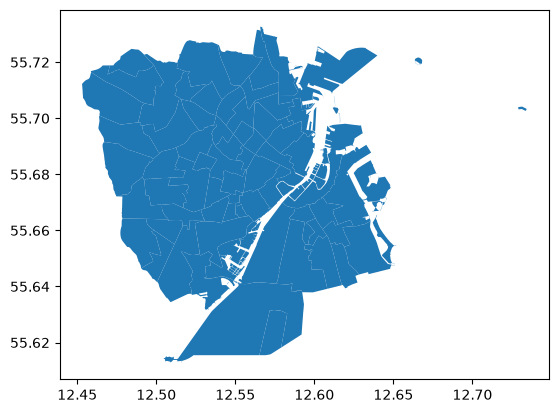

In [9]:
cph.plot()

In [10]:
cph.explore()

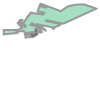

In [19]:
cph.loc[27, 'geometry']

In [20]:
cph.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

"To obtain area measurements, first make sure your `GeoDataFrame` is in a *projected* CRS. GeoPandas will issue a warning if you try to do distance or area computations in a geographic CRS." (from GDS lec 2)

In [21]:
cph.area.head()

/var/folders/j3/746qr67x2xj8z46fp8cgvc080000gn/T/ipykernel_83827/3155762756.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cph.area.head()


0    0.000174
1    0.000095
2    0.000061
3    0.000185
4    0.000147
dtype: float64

We get a warning because our CRS is geographic, not projected. Distances would be measured in degrees instead of e.g. metres. Change the geometries to a projected CRS:

<Axes: >

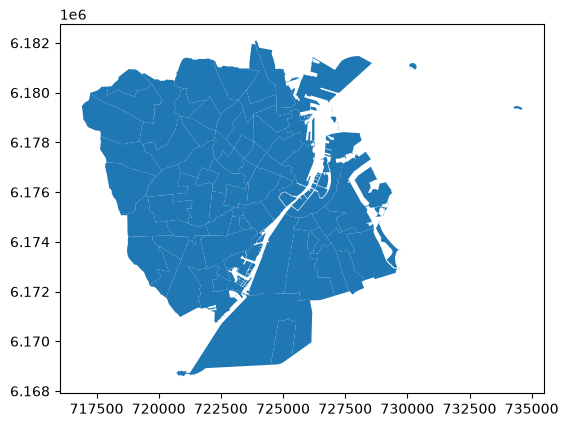

In [24]:
cph_proj = cph.to_crs(epsg=25832)
cph_proj.plot()

<Axes: >

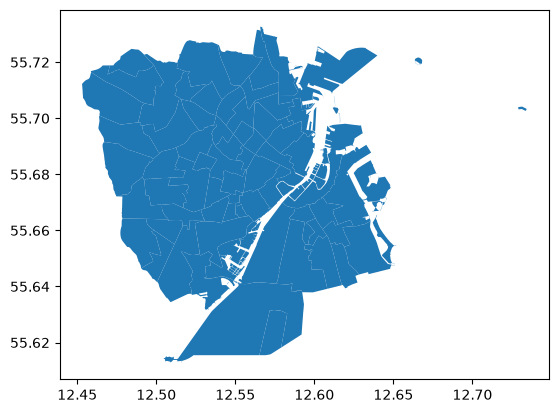

In [25]:
cph.plot()

In [26]:
cph_proj.area.head()

0    1.217523e+06
1    6.625149e+05
2    4.247127e+05
3    1.295991e+06
4    1.027538e+06
dtype: float64

In [28]:
# Find centroids
centroids = cph_proj.centroid
centroids.head()

0     POINT (721603.93 6177292.076)
1    POINT (722390.193 6175433.261)
2    POINT (721921.675 6176599.409)
3    POINT (720325.726 6176357.725)
4    POINT (722708.058 6176548.017)
dtype: geometry

<Axes: >

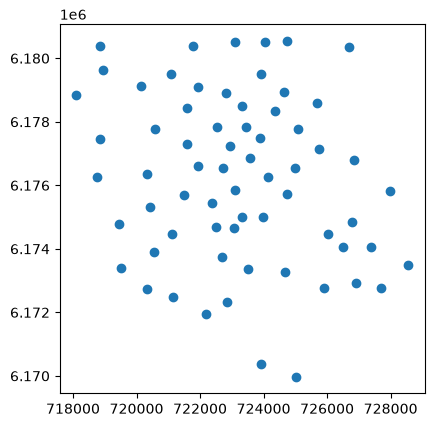

In [29]:
centroids.plot()

In [31]:
import matplotlib.pyplot as plt

<Axes: >

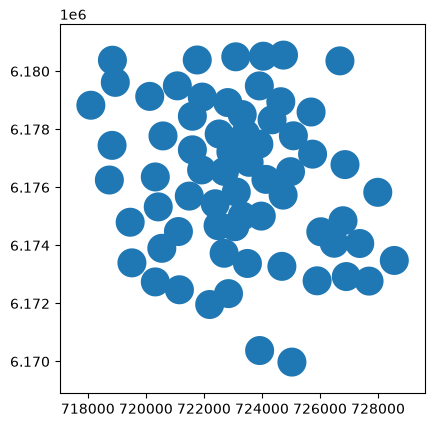

In [32]:
buf = centroids.buffer(500)
f, ax = plt.subplots(1)
buf.plot(ax=ax, linewidth=0)

In [33]:
import contextily as cx

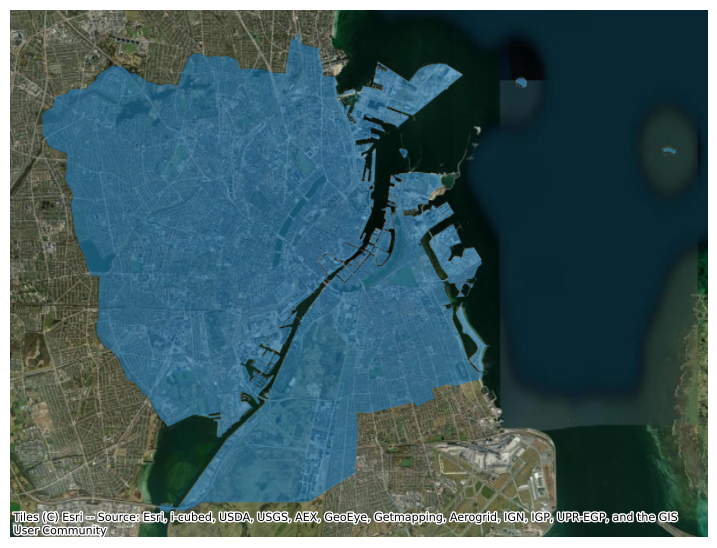

In [36]:
f, ax = plt.subplots(1, figsize=(9, 9))
cph.plot(alpha=0.6, ax=ax)
cx.add_basemap(
    ax, 
    crs=cph.crs,
    source=cx.providers.Esri.WorldImagery
)
ax.set_axis_off()

In [38]:
import shapely

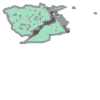

In [40]:
# Merge polygons

polygon = shapely.unary_union(cph.geometry)
polygon

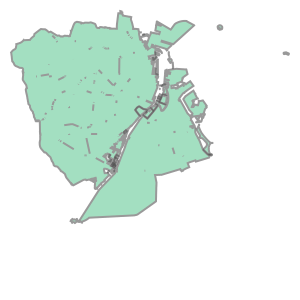

In [41]:
polygon_proj = shapely.unary_union(cph_proj.geometry)
polygon_proj